In [1]:
import os
import pandas as pd

# paths
labels_path = r"d:\Users\FINE LAPTOP\Desktop\noor ml project\labels.csv"
base_folder = r"d:\Users\FINE LAPTOP\Desktop\noor ml project"

df = pd.read_csv(labels_path)

valid_rows = []

for idx, row in df.iterrows():
    filename = row['path']
    label = row['label']

    folder = "black" if label == 1 else "white"
    full_path = os.path.join(base_folder, filename)

    if os.path.exists(full_path):
        valid_rows.append(row)
# Create cleaned dataframe
clean_df = pd.DataFrame(valid_rows)

print("Old dataset size:", len(df))
print("New dataset size:", len(clean_df))

# Save cleaned CSV
clean_df.to_csv(labels_path.replace(".csv", "_cleaned.csv"), index=False)

print("Saved cleaned file as:", labels_path.replace(".csv", "_cleaned.csv"))


Old dataset size: 10246
New dataset size: 9905
Saved cleaned file as: d:\Users\FINE LAPTOP\Desktop\noor ml project\labels_cleaned.csv


In [16]:
import os
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# --- Load cleaned CSV ---
labels_path = r"d:\Users\FINE LAPTOP\Desktop\noor ml project\labels_cleaned.csv"
base_folder = r"d:\Users\FINE LAPTOP\Desktop\noor ml project"

df = pd.read_csv(labels_path)

# --- Load file contents ---
texts = []
labels = []

for idx, row in df.iterrows():
    full_path = os.path.join(base_folder, row['path'])
    label = row['label']
    
    try:
        with open(full_path, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
        texts.append(content)
        labels.append(label)
    except Exception as e:
        print("Error reading file:", full_path, e)

# --- Vectorize text files ---
vectorizer = TfidfVectorizer(max_features=5000)  # You can adjust max_features
X = vectorizer.fit_transform(texts)
y = pd.Series(labels)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

# --- Split dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# --- Train MLP Classifier multi layer perceptron---
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', max_iter=50, random_state=42)
mlp.fit(X_train, y_train)

# --- Evaluate ---
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


Feature matrix shape: (9905, 5000)
Labels shape: (9905,)
Training Accuracy: 0.9998557622962643
Test Accuracy: 0.9983176312247645


In [17]:
import os
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# --- Train Naive Bayes Classifier ---
nb = MultinomialNB()
nb.fit(X_train, y_train)

# --- Predict ---
y_pred = nb.predict(X_test)
y_proba = nb.predict_proba(X_test)[:, 1]  # Probability of positive class (Webshell)

# --- Evaluate performance ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_value = roc_auc_score(y_test, y_proba)

print("=== Naive Bayes Performance ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (TPR): {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc_value:.5f}\n")

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

=== Naive Bayes Performance ===
Accuracy: 0.9845
Precision: 0.9767
Recall (TPR): 0.4828
F1-score: 0.6462
AUC: 0.99610

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      2885
           1       0.98      0.48      0.65        87

    accuracy                           0.98      2972
   macro avg       0.98      0.74      0.82      2972
weighted avg       0.98      0.98      0.98      2972

Confusion Matrix:
 [[2884    1]
 [  45   42]]


In [4]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import os
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb

# --- Train XGBoost Classifier ---
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_clf.fit(X_train, y_train)

# --- Predict ---
y_pred_xg = xgb_clf.predict(X_test)
y_proba_xg = xgb_clf.predict_proba(X_test)[:, 1]

# --- Evaluate performance ---
accuracy = accuracy_score(y_test, y_pred_xg)
precision = precision_score(y_test, y_pred_xg)
recall = recall_score(y_test, y_pred_xg)
f1 = f1_score(y_test, y_pred_xg)
auc_value = roc_auc_score(y_test, y_proba_xg)

print("=== XGBoost Performance ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (TPR): {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc_value:.5f}\n")

print("Classification Report:\n", classification_report(y_test, y_pred_xg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xg))

C:\Users\FINE LAPTOP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:18:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost Performance ===
Accuracy: 0.9983
Precision: 1.0000
Recall (TPR): 0.9425
F1-score: 0.9704
AUC: 0.99979

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2885
           1       1.00      0.94      0.97        87

    accuracy                           1.00      2972
   macro avg       1.00      0.97      0.98      2972
weighted avg       1.00      1.00      1.00      2972

Confusion Matrix:
 [[2885    0]
 [   5   82]]


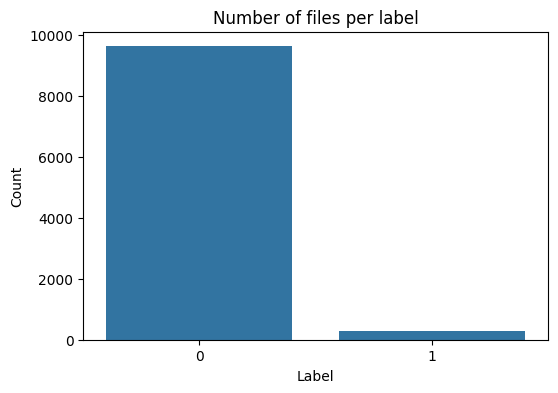

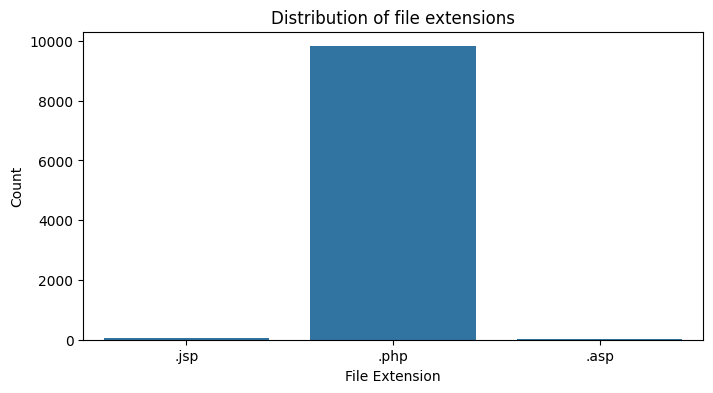

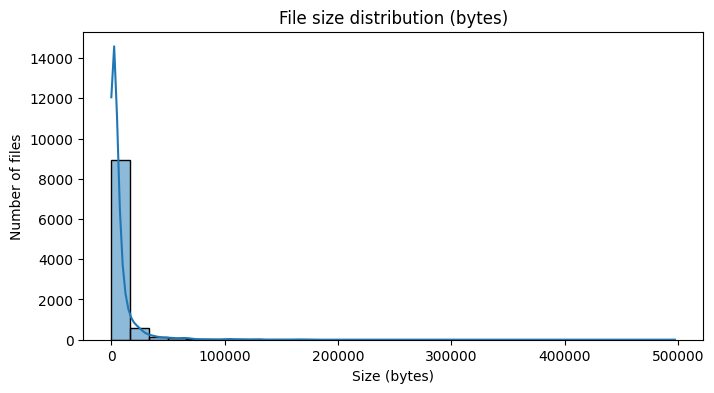

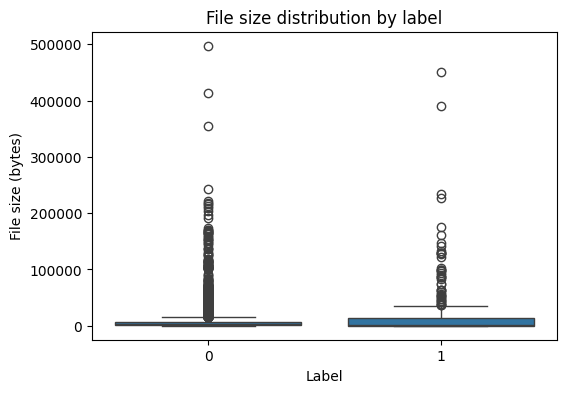

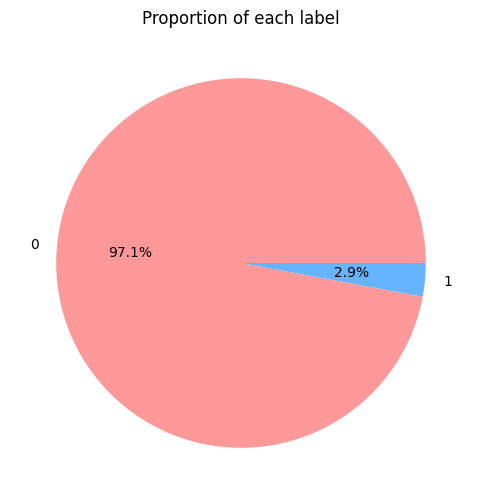

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# --- Load cleaned CSV ---
labels_path = r"d:\Users\FINE LAPTOP\Desktop\noor ml project\labels_cleaned.csv"
df = pd.read_csv(labels_path)

# --- 1. Count of files per label ---
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Number of files per label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# --- 2. File extension distribution ---
df['extension'] = df['path'].apply(lambda x: os.path.splitext(x)[1])
plt.figure(figsize=(8,4))
sns.countplot(x='extension', data=df)
plt.title("Distribution of file extensions")
plt.xlabel("File Extension")
plt.ylabel("Count")
plt.show()

# --- 3. File size distribution ---
# Calculate file sizes
def get_file_size(path):
    try:
        return os.path.getsize(os.path.join(r"d:\Users\FINE LAPTOP\Desktop\noor ml project", path))
    except:
        return np.nan

df['size_bytes'] = df['path'].apply(get_file_size)

plt.figure(figsize=(8,4))
sns.histplot(df['size_bytes'], bins=30, kde=True)
plt.title("File size distribution (bytes)")
plt.xlabel("Size (bytes)")
plt.ylabel("Number of files")
plt.show()

# --- 4. Boxplot of file size by label ---
plt.figure(figsize=(6,4))
sns.boxplot(x='label', y='size_bytes', data=df)
plt.title("File size distribution by label")
plt.xlabel("Label")
plt.ylabel("File size (bytes)")
plt.show()

# --- 5. Pie chart of labels ---
label_counts = df['label'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title("Proportion of each label")
plt.show()


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# --- Predict labels and probabilities ---
y_pred = mlp.predict(X_test)
y_proba = mlp.predict_proba(X_test)[:, 1]  # probability of positive class (Webshell)

# --- Calculate metrics ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_value = roc_auc_score(y_test, y_proba)

# --- Build summary table ---
summary = {
    "Model Name": ["MLP_WebFiles"],
    "Accuracy": [round(accuracy, 4)],
    "Precision": [round(precision, 4)],
    "Recall (TPR)": [round(recall, 4)],
    "F1-score": [round(f1, 4)],
    "AUC Value": [round(auc_value, 5)],
    "Meaning": ["Area Under the Curve (AUC) evaluates classifier's ability to distinguish classes"],
    "False Positive Rate (FPR)": ["Frequency of incorrectly identifying non-Webshell as Webshell"],
    "Performance Evaluation": ["Higher values indicate better performance"],
    "Ideal AUC Value": ["1 (Perfect Classifier)"],
    "Random Classifier": ["0.5"],
    "Model Performance": ["Excellent performance in distinguishing Webshell vs non-Webshell"]
}

summary_df = pd.DataFrame(summary)

# --- Display the table ---
print(summary_df)


     Model Name  Accuracy  Precision  Recall (TPR)  F1-score  AUC Value  \
0  MLP_WebFiles    0.9983     0.9881         0.954    0.9708    0.99993   

                                             Meaning  \
0  Area Under the Curve (AUC) evaluates classifie...   

                           False Positive Rate (FPR)  \
0  Frequency of incorrectly identifying non-Websh...   

                      Performance Evaluation         Ideal AUC Value  \
0  Higher values indicate better performance  1 (Perfect Classifier)   

  Random Classifier                                  Model Performance  
0               0.5  Excellent performance in distinguishing Webshe...  


In [12]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_train_proba = mlp.predict_proba(X_train)[:, 1]
y_test_proba  = mlp.predict_proba(X_test)[:, 1]

# Predicted probabilities for Naive Bayes
y_train_proba_nb = nb.predict_proba(X_train)[:, 1]  # Train set probabilities
y_test_proba_nb  = nb.predict_proba(X_test)[:, 1]   # Test set probabilities

y_train_proba_xg = xgb_clf.predict_proba(X_train)[:, 1]
y_test_proba_xg  = xgb_clf.predict_proba(X_test)[:, 1]

# --- Define function to calculate metrics ---
def get_metrics(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    return acc, prec, rec, f1, auc

# --- Use test set predictions and probabilities consistently ---
# MLP
metrics_mlp = get_metrics(y_test, y_test_pred, y_test_proba)
metrics_nb  = get_metrics(y_test, y_pred, y_proba)
metrics_xgb = get_metrics(y_test, y_pred_xg, y_proba_xg)

# --- Create comparison table ---
comparison_df = pd.DataFrame({
    "Model": ["MLP", "Naive Bayes", "XGBoost"],
    "Accuracy": [round(metrics_mlp[0],4), round(metrics_nb[0],4), round(metrics_xgb[0],4)],
    "Precision": [round(metrics_mlp[1],4), round(metrics_nb[1],4), round(metrics_xgb[1],4)],
    "Recall (TPR)": [round(metrics_mlp[2],4), round(metrics_nb[2],4), round(metrics_xgb[2],4)],
    "F1-score": [round(metrics_mlp[3],4), round(metrics_nb[3],4), round(metrics_xgb[3],4)],
    "AUC": [round(metrics_mlp[4],5), round(metrics_nb[4],5), round(metrics_xgb[4],5)]
})

print(comparison_df)


         Model  Accuracy  Precision  Recall (TPR)  F1-score      AUC
0          MLP    0.9985     0.9825        0.9655    0.9739  0.99992
1  Naive Bayes    0.9985     0.9825        0.9655    0.9739  0.99992
2      XGBoost    0.9980     1.0000        0.9310    0.9643  0.99989


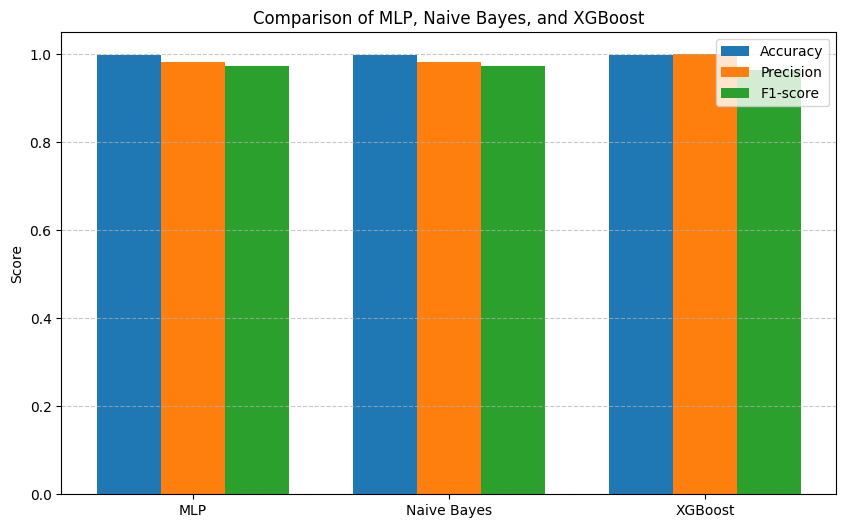

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# --- Metrics for visualization ---
models = ["MLP", "Naive Bayes", "XGBoost"]

accuracy = [metrics_mlp[0], metrics_nb[0], metrics_xgb[0]]
precision = [metrics_mlp[1], metrics_nb[1], metrics_xgb[1]]
f1 = [metrics_mlp[3], metrics_nb[3], metrics_xgb[3]]

# --- Plotting ---
x = np.arange(len(models))
width = 0.25  # width of the bars

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width, accuracy, width, label='Accuracy')
ax.bar(x, precision, width, label='Precision')
ax.bar(x + width, f1, width, label='F1-score')

# Labels and formatting
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Comparison of MLP, Naive Bayes, and XGBoost')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
